# 📘 Principal Component Analysis (PCA) – Complete Theory

## 1. Introduction
- **Principal Component Analysis (PCA)** is an **unsupervised dimensionality reduction technique**.
- It transforms high-dimensional data into a lower-dimensional space while preserving as much variance (information) as possible.
- PCA is widely used in **data preprocessing, visualization, and noise reduction**.

---

## 2. Key Concepts
### 🔹 Dimensionality Reduction
- Many datasets have too many features (high-dimensional).
- PCA reduces the number of features while keeping the most important information.

### 🔹 Variance
- PCA focuses on directions (components) where data varies the most.
- More variance = more information.

### 🔹 Principal Components
- New axes (directions) created by PCA.
- Ordered by importance:
  - **PC1** → captures maximum variance.
  - **PC2** → captures second most variance, orthogonal to PC1.
  - And so on…

---

## 3. How PCA Works (Step by Step)
1. **Standardize the data** (mean = 0, variance = 1).
2. **Compute covariance matrix** to understand relationships between features.
3. **Calculate eigenvalues and eigenvectors** of the covariance matrix.
   - Eigenvectors → directions of principal components.
   - Eigenvalues → amount of variance captured by each component.
4. **Sort eigenvectors by eigenvalues** (descending order).
5. **Select top k components** to reduce dimensionality.
6. **Transform data** into the new reduced feature space.

---

## 4. Mathematical Foundation
- Covariance matrix:  
  

\[
  C = \frac{1}{n-1} X^T X
  \]


- Eigen decomposition:  
  

\[
  C v = \lambda v
  \]


  - \(v\) = eigenvector (principal component direction).
  - \(\lambda\) = eigenvalue (variance captured).

---

## 5. Advantages of PCA
- Reduces dimensionality → faster computation.
- Removes noise and redundancy.
- Helps visualize high-dimensional data.
- Improves performance of ML algorithms by avoiding overfitting.

---

## 6. Limitations of PCA
- Assumes linear relationships.
- Principal components may be hard to interpret.
- Sensitive to scaling → requires data standardization.
- May lose some information when reducing dimensions.

---

## 7. Applications
- Data visualization (2D/3D plots of high-dimensional data).
- Image compression.
- Noise reduction in signals.
- Preprocessing step in machine learning pipelines.
- Genomics, finance, and text mining.

---

## 8. Example Intuition
- Imagine a dataset with 100 features.
- PCA finds the top few directions (say 2 or 3) that capture most of the variance.
- Instead of working with 100 features, you can work with just those 2–3 principal components.

---

## 9. Summary
- **PCA = Dimensionality reduction technique.**
- Finds new axes (principal components) that maximize variance.
- Uses **eigenvalues/eigenvectors** of covariance matrix.
- Best suited for preprocessing, visualization, and reducing noise in high-dimensional datasets.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [6]:
df = pd.read_csv("C:\\Users\\HP\\OneDrive\\Documents\\DataMites\\Machine learning\\winequality_red.csv")

In [7]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [9]:
df.shape

(1599, 12)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [11]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [12]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [14]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

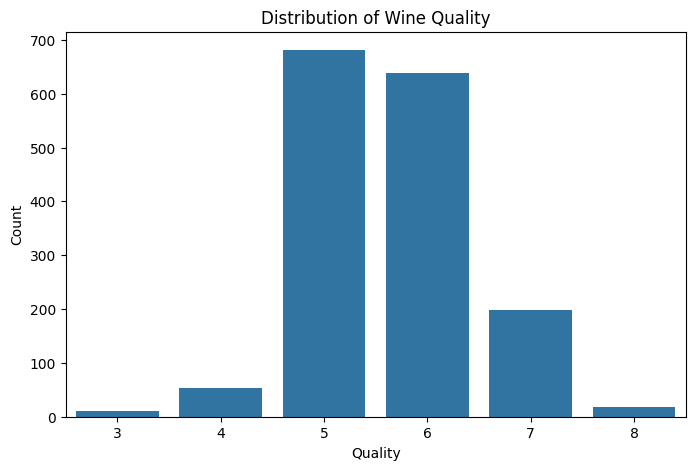

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=df)
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

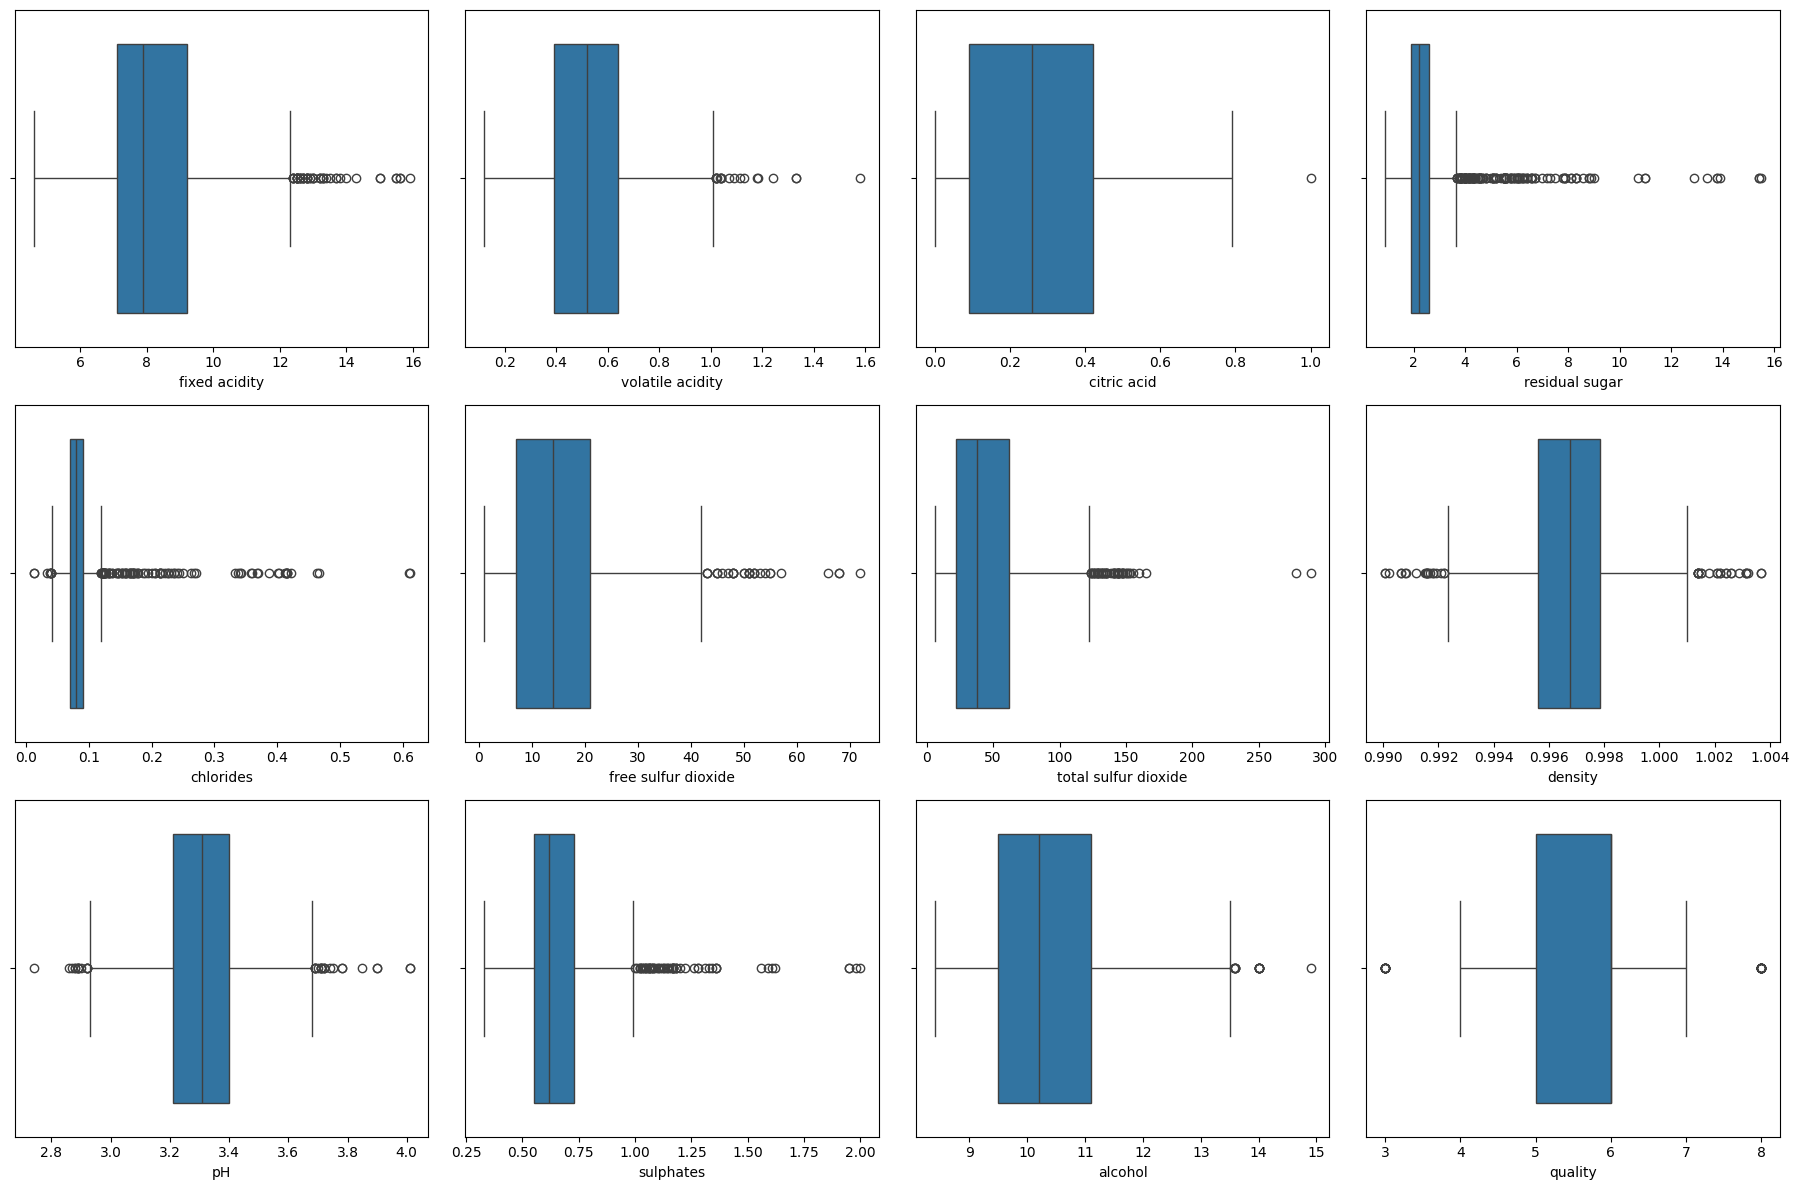

In [16]:
plt.figure(figsize=(18,12))

plotnumber = 1

for column in df.columns:
    if plotnumber <= 12:
        ax = plt.subplot(3,4,plotnumber)
        sns.boxplot(x=df[column])
        plt.xlabel(column)
        plotnumber += 1

plt.tight_layout()
plt.show()

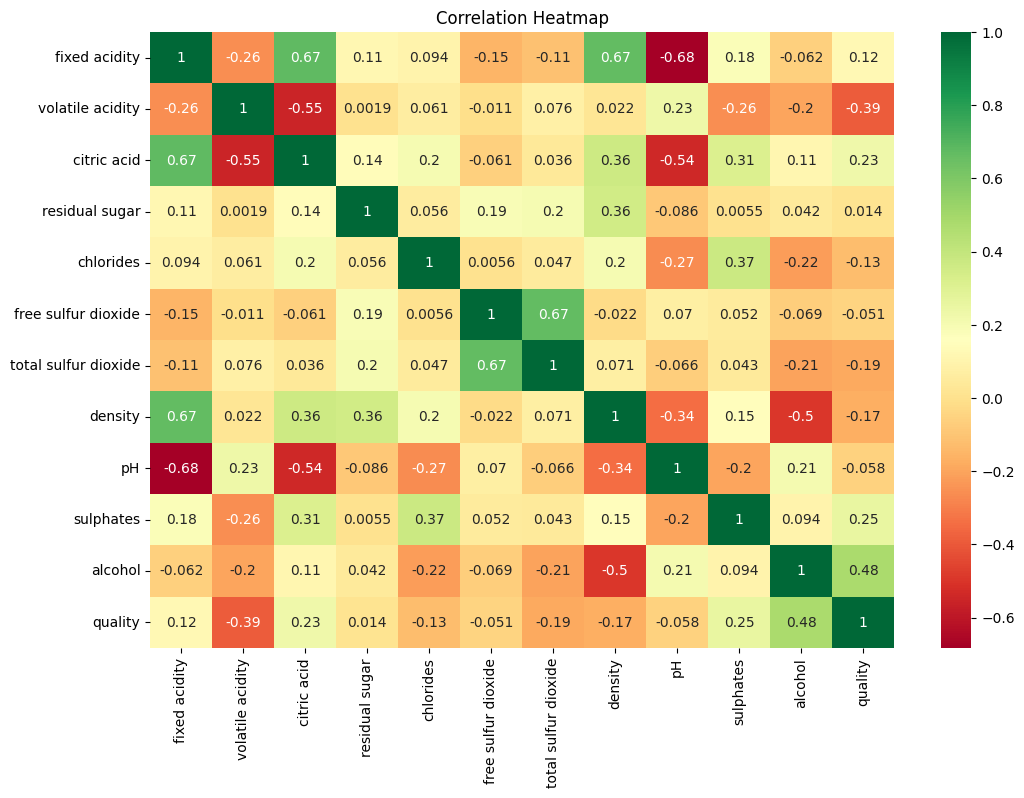

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='RdYlGn'
)

plt.title('Correlation Heatmap')
plt.show()

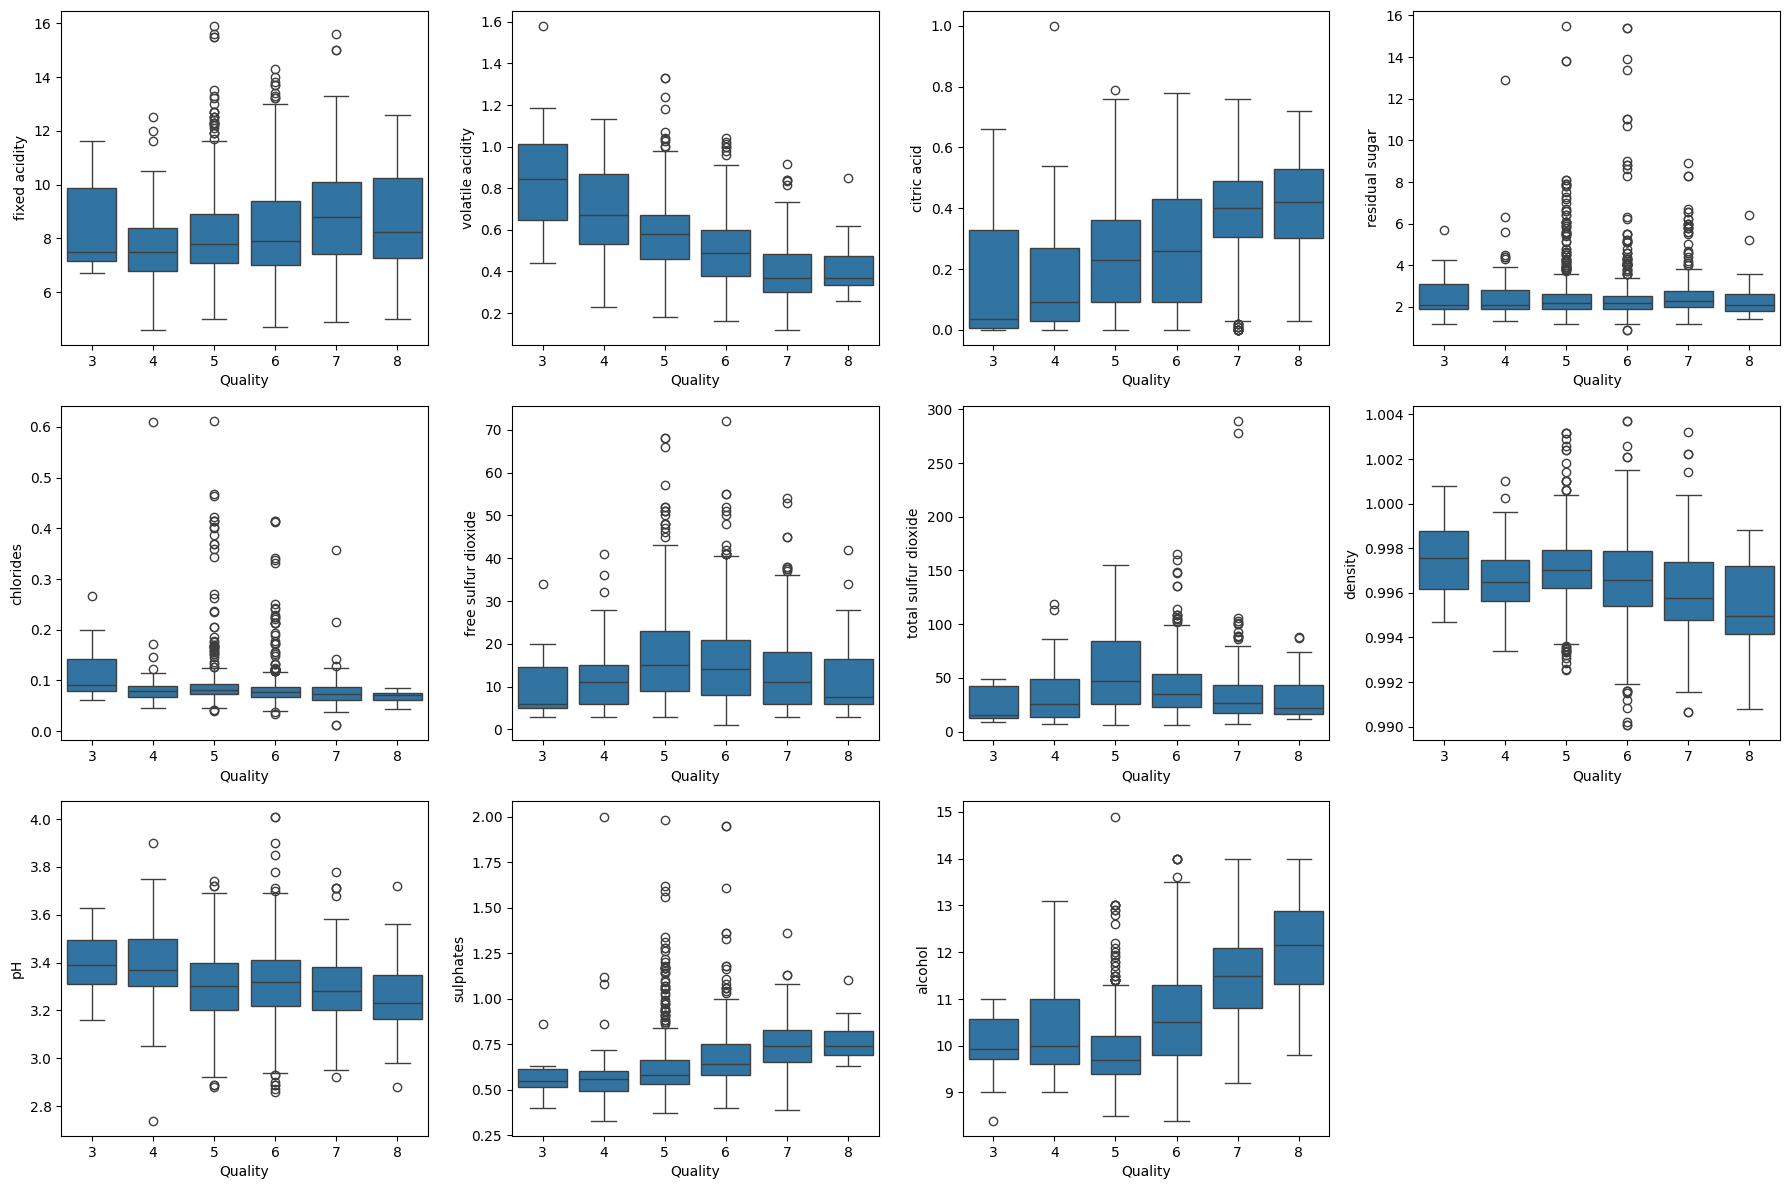

In [18]:
plt.figure(figsize=(18,12))

plotnumber = 1

for column in df.columns:
    if column != 'quality':
        ax = plt.subplot(3,4,plotnumber)
        sns.boxplot(x='quality', y=column, data=df)
        plt.xlabel('Quality')
        plt.ylabel(column)
        plotnumber += 1

plt.tight_layout()
plt.show()

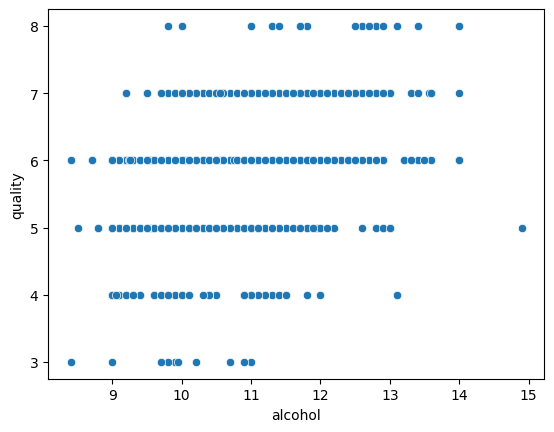

In [19]:
sns.scatterplot(data=df, x='alcohol', y='quality')
plt.show()

In [22]:
df.quality.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [20]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [31]:
X = df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']]
y = df['quality']

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)

In [33]:
from sklearn.decomposition import PCA
pca = PCA(n_components= 2)

X_train = pca.fit_transform(X_train)
X_test = pca.fit_transform(X_test)

In [34]:
## covariance is used to find the correlation between features
pca.get_covariance()[0]


array([ 7.51639431e-01,  2.91758885e-03,  4.78409224e-04, -9.35287011e-02,
       -1.95740348e-04, -2.69358428e+00, -4.99139014e+00,  1.46524229e-05,
       -2.26455770e-03, -5.01677791e-04,  1.34835925e-02])

In [35]:
variance = pca.explained_variance_ratio_
variance

array([0.95285953, 0.04263974])

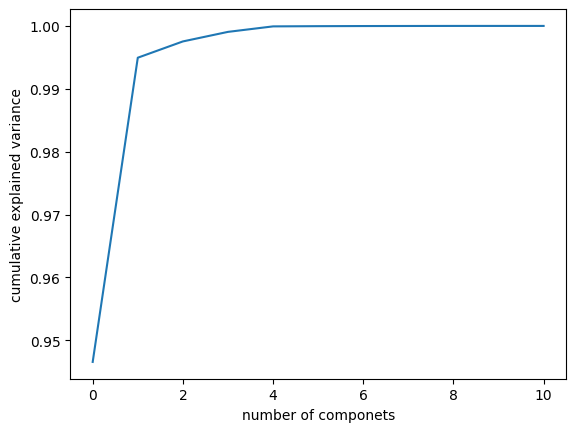

In [37]:
pca = PCA().fit(X)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel(("number of componets"))
plt.ylabel(('cumulative explained variance'))
plt.show()